In [39]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("zanieczyszczenia.xlsx", sheet_name="PM2,5", skiprows=lambda x: x == 1)
df = df[
    (df['Rok'] >= 2010) &
    (df['Rok'] <= 2023) &
    (df['Czas uśredniania'] == '24g')
][['Rok', 'Województwo', 'Kod stacji', 'Średnia']]
df


,Rok,Województwo,Kod stacji,Średnia
68,2010,dolnośląskie,DsWrocNaGrob,31.917891
70,2010,dolnośląskie,DsWrocWybCon,37.649151
71,2010,dolnośląskie,DsLegAlRzecz,30.791925
72,2010,dolnośląskie,DsWalbrzWyso,27.912426
73,2010,dolnośląskie,DsOsieczow21,17.471042
...,...,...,...,...
1661,2023,wielkopolskie,WpPleszAlMic,19.149107
1662,2023,zachodniopomorskie,ZpSzczAndrze,10.539178
1664,2023,zachodniopomorskie,ZpKoszSpasow,11.168219
1665,2023,zachodniopomorskie,ZpMyslZaBram,14.984022


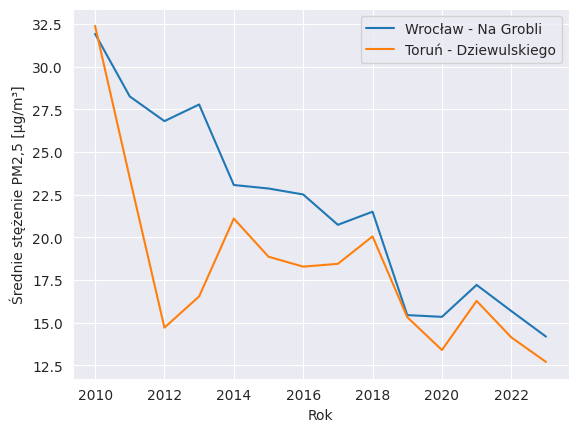

In [33]:
station1 = df[df['Kod stacji'] == "DsWrocNaGrob"][['Rok', 'Średnia']]
station2 = df[df['Kod stacji'] == "KpToruDziewu"][['Rok', 'Średnia']]

plt.plot(station1['Rok'], station1['Średnia'], label='Wrocław - Na Grobli')
plt.plot(station2['Rok'], station2['Średnia'], label='Toruń - Dziewulskiego')
plt.xlabel('Rok')
plt.ylabel('Średnie stężenie PM2,5 [µg/m³]')
plt.legend()
plt.show()

From 2010 to 2023, the average PM2.5 concentration in the air in Toruń was higher than in Wrocław. In both cities, there is a downward trend in the PM2.5 concentration.

<module 'matplotlib.pyplot' from '/home/marcin/.local/lib/python3.13/site-packages/matplotlib/pyplot.py'>

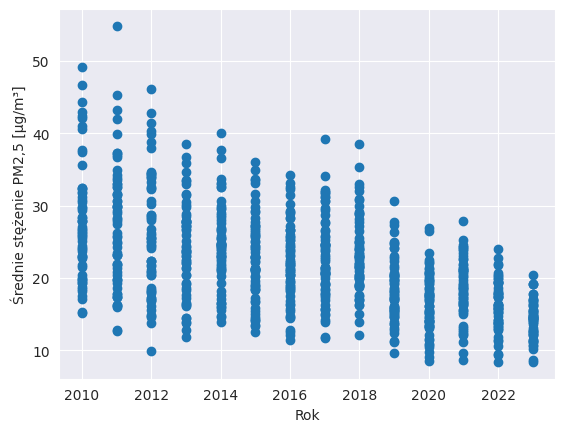

In [38]:
plt.scatter(df['Rok'], df['Średnia'])
plt.xlabel('Rok')
plt.ylabel('Średnie stężenie PM2,5 [µg/m³]')
plt

The distribution of average PM2.5 concentrations in Poland from 2010 to 2023 shows a downward trend. In 2010, the average PM2.5 concentration was higher than in 2023. The range of PM2.5 concentrations in 2010 was much larger than in 2023.

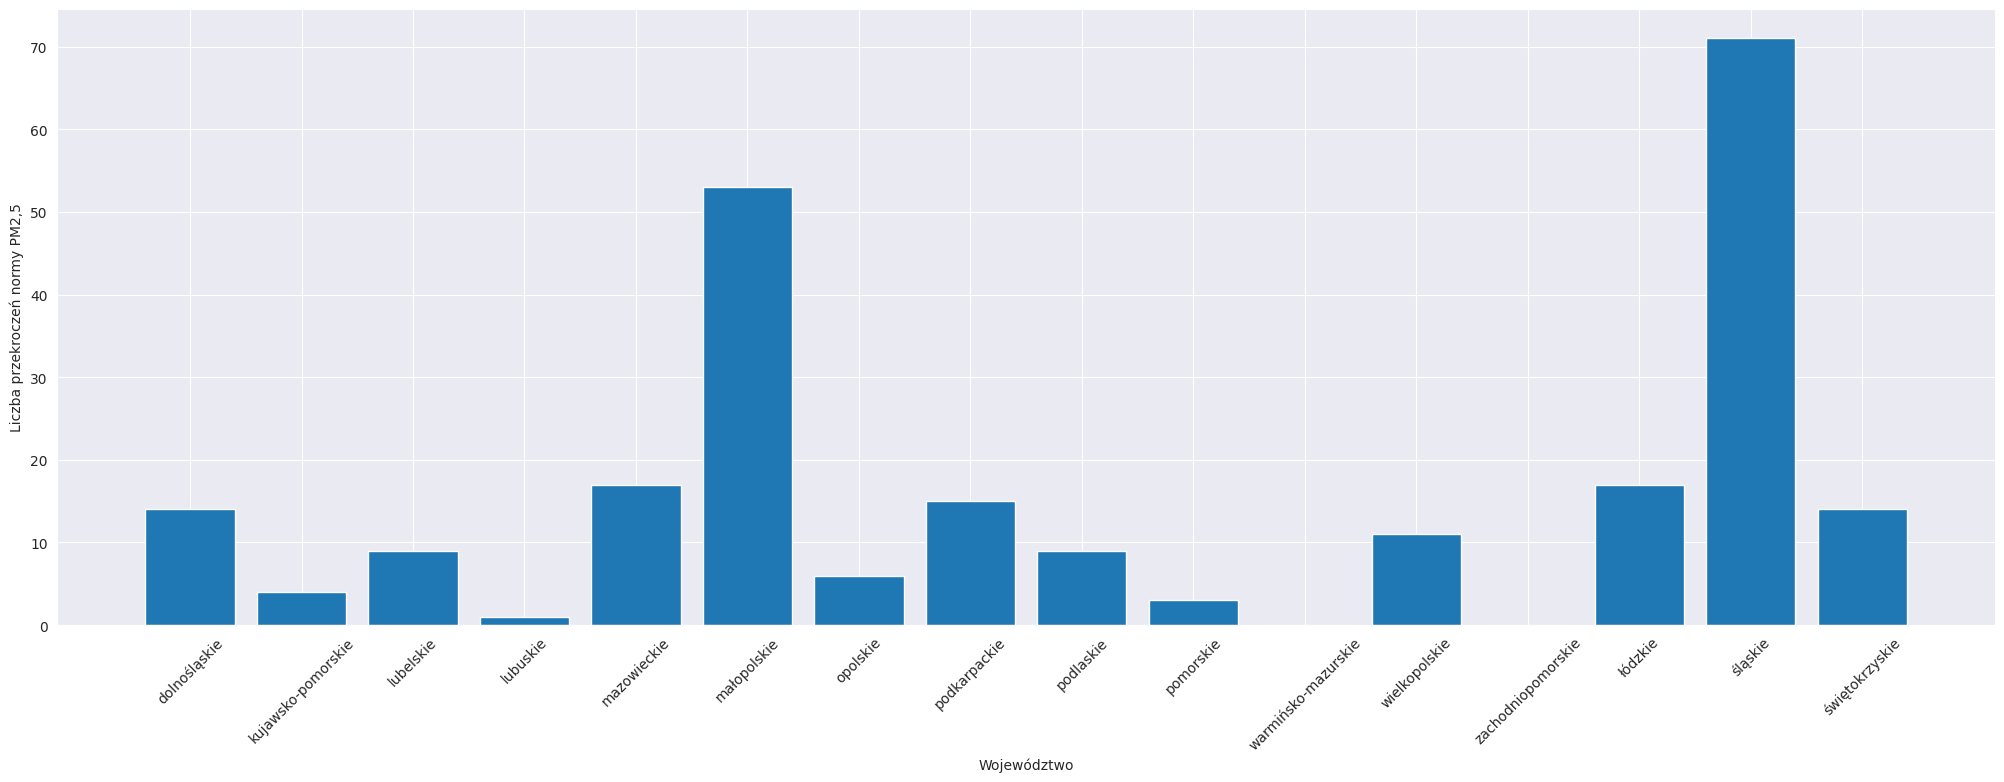

In [79]:
exceeding_sum = df[df['Średnia'] > 25].groupby('Województwo').size()
all_groups = df['Województwo'].unique()
exceeding_sum = exceeding_sum.reindex(all_groups, fill_value=0)
exceeding_sum = exceeding_sum.sort_index()
plt.figure(figsize=(25,8))
plt.bar(exceeding_sum.index, exceeding_sum.values)
plt.xlabel('Województwo')
plt.ylabel('Liczba przekroczeń normy PM2,5')
plt.xticks(rotation=45)
plt.show()

From 2010 to 2023, the most exceedances of the PM2.5 concentration standard occurred in the Silesian Voivodeship, and the fewest in the Warmian-Masurian and West Pomeranian Voivodeships.

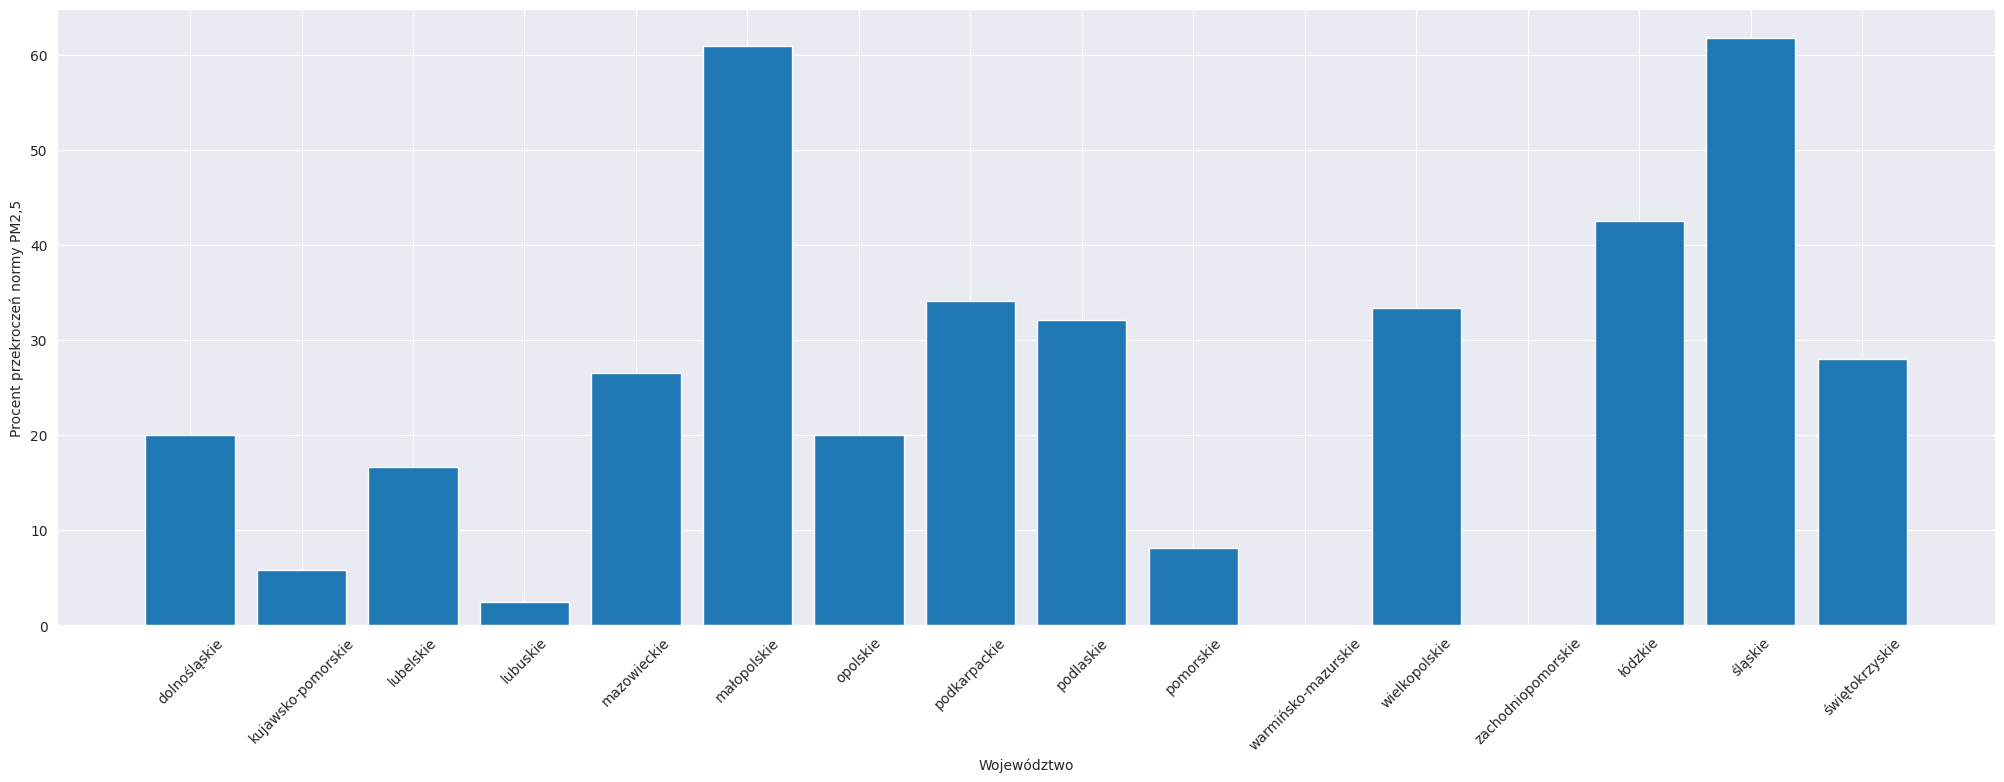

In [80]:
exceeding_percent = exceeding_sum / df.groupby('Województwo').size() * 100
plt.figure(figsize=(25,8))
plt.bar(exceeding_percent.index, exceeding_percent.values)
plt.xlabel('Województwo')
plt.ylabel('Procent przekroczeń normy PM2,5')
plt.xticks(rotation=45)
plt.show()

Additionally, the percentage of exceedances of the PM2.5 standard was highest in the Silesian Voivodeship, and lowest in the Warmian-Masurian and West Pomeranian Voivodeships.